In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt


In [2]:
file_path = "E:/7th semester/Deep Learning/labs/DL-Assigment/data/BAJAJ-AUTO.csv"

data = pd.read_csv(file_path)
data.head(100)

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2008-05-26,BAJAJ-AUTO,EQ,2101.05,898.00,898.00,551.35,600.25,604.75,624.61,3972485,2.481245e+14,NaN,1202933,0.3028
1,2008-05-27,BAJAJ-AUTO,EQ,604.75,624.70,639.00,580.30,595.50,593.15,606.43,1751063,1.061901e+14,NaN,369389,0.2110
2,2008-05-28,BAJAJ-AUTO,EQ,593.15,561.65,621.90,561.65,605.10,608.15,608.75,1652355,1.005877e+14,NaN,898602,0.5438
3,2008-05-29,BAJAJ-AUTO,EQ,608.15,619.40,619.40,576.00,600.00,599.45,600.98,669269,4.022165e+13,NaN,449951,0.6723
4,2008-05-30,BAJAJ-AUTO,EQ,599.45,605.40,607.00,538.00,576.25,571.70,565.55,1262117,7.137937e+13,NaN,936432,0.7420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2008-10-10,BAJAJ-AUTO,EQ,544.15,501.10,524.90,425.00,425.00,462.65,500.20,208322,1.042023e+13,NaN,179589,0.8621
96,2008-10-13,BAJAJ-AUTO,EQ,462.65,457.00,527.90,450.00,511.00,514.50,500.36,153103,7.660593e+12,NaN,124001,0.8099
97,2008-10-14,BAJAJ-AUTO,EQ,514.50,527.00,590.65,525.00,534.00,540.60,557.36,183201,1.021090e+13,NaN,153074,0.8356
98,2008-10-15,BAJAJ-AUTO,EQ,540.60,523.05,545.00,459.50,544.00,529.20,498.19,156439,7.793700e+12,NaN,130055,0.8313


In [3]:
data.shape

(3202, 15)

In [4]:
data.isnull().sum()


Date                    0
Symbol                  0
Series                  0
Prev Close              0
Open                    0
High                    0
Low                     0
Last                    0
Close                   0
VWAP                    0
Volume                  0
Turnover                0
Trades                746
Deliverable Volume      0
%Deliverble             0
dtype: int64

In [5]:
# # Drop missing values
# data = data.dropna()
# data

In [6]:
## to describe the dataset
data.describe()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,3202.000000,3202.000000,3202.000000,3202.000000,3202.000000,3202.000000,3202.000000,3.202000e+03,3.202000e+03,2456.000000,3.202000e+03,3202.000000
mean,2189.871065,2191.537883,2219.934510,2162.215209,2190.307917,2190.412196,2191.294288,4.114639e+05,9.644024e+13,27487.876629,1.944837e+05,0.509401
std,774.552766,776.148452,781.289529,770.192017,775.065896,775.095766,775.657353,3.911067e+05,1.174628e+14,19453.983219,1.707922e+05,0.172869
min,301.900000,262.000000,307.050000,262.000000,300.000000,301.900000,301.980000,4.966000e+03,2.497018e+11,451.000000,1.290000e+03,0.073000
25%,1661.925000,1663.250000,1693.775000,1636.362500,1660.512500,1661.925000,1664.845000,2.054658e+05,4.228246e+13,16041.250000,9.553850e+04,0.391225
50%,2269.950000,2270.000000,2305.575000,2240.250000,2270.750000,2270.225000,2269.900000,3.125365e+05,6.885321e+13,22822.000000,1.537390e+05,0.520000
75%,2808.437500,2810.000000,2834.950000,2778.362500,2808.975000,2808.487500,2808.565000,5.000315e+05,1.107763e+14,32952.250000,2.456250e+05,0.626675
max,4237.450000,4260.000000,4361.400000,4200.000000,4236.000000,4237.450000,4260.500000,8.537143e+06,3.436565e+15,398043.000000,4.154492e+06,1.000000


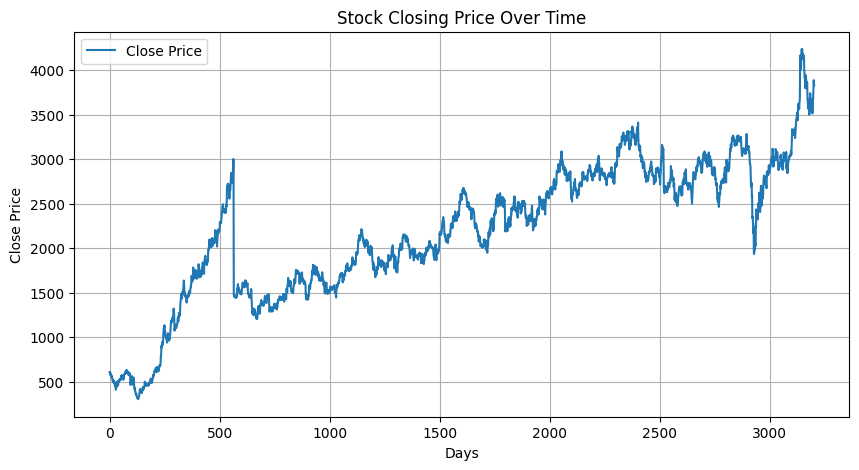

In [7]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'], label='Close Price')
plt.title("Stock Closing Price Over Time")
plt.xlabel("Days")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()


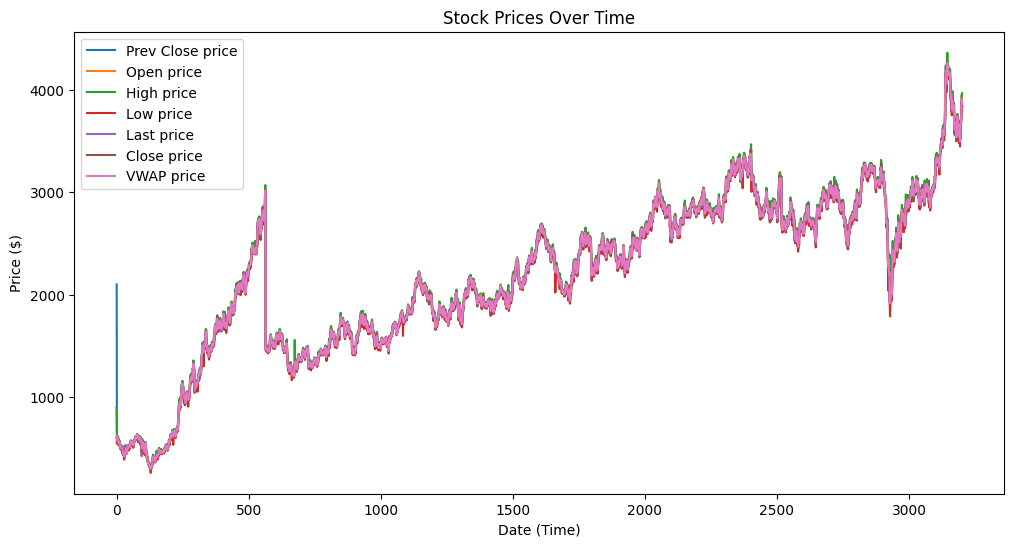

In [8]:
## Visualize the prev price,open price, close price,prev close price , high price, last price and law price belongs to the  company

prev_close = data['Prev Close']
open_price = data['Open']
high_price = data['High']
low_price = data['Low']
last_price = data['Last']
close_price = data['Close']
vwap_price = data['VWAP']

plt.figure(figsize=(12,6))

plt.plot(prev_close,label='Prev Close price')
plt.plot(open_price,label='Open price')
plt.plot(high_price,label='High price')
plt.plot(low_price,label='Low price')
plt.plot(last_price,label='Last price')
plt.plot(close_price,label='Close price')
plt.plot(vwap_price,label='VWAP price')

plt.legend()
plt.xlabel("Date (Time)")
plt.ylabel("Price ($)")
plt.title("Stock Prices Over Time")
plt.show()


In [9]:
## conclusion - after ploting prev price,open price, close price,prev close price , high price, last price and law price columns those 
# are approximately same variation. then can be consider only one column without getting all these columns for the prediction

In [10]:
## finally can be select to predict the close price of the dataset